<a href="https://colab.research.google.com/github/alvinadar/Predicting-customer-curn-rate-using-decision-tree-model/blob/main/50_1_Customer_Curn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Goal: A telecom company wants to know which customers are likely to leave ("churn") so they can offer them deals before they cancel. Build a classifier to predict churn.

#Import Library

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

#Create a dataset

In [13]:
np.random.seed(42)
n = 1000  # 1000 customers

data = pd.DataFrame({
    'tenure_months':   np.random.randint(1, 72, n),      # how long they've been a customer
    'monthly_charges': np.random.uniform(20, 120, n).round(2),
    'contract_type':   np.random.choice(['Month-to-month', 'One year', 'Two year'], n),
    'tech_support':    np.random.choice(['Yes', 'No'], n),
    'num_complaints':  np.random.poisson(1, n),          # support tickets
})


# Create a realistic "churn" outcome: short tenure + high bills + complaints = more likely to leave
churn_score = (
    (data['tenure_months'] < 12).astype(int) * 2 +
    (data['monthly_charges'] > 80).astype(int) +
    (data['contract_type'] == 'Month-to-month').astype(int) * 2 +
    data['num_complaints']
)
data['churn'] = ((churn_score + np.random.normal(0, 1, n)) > 4).astype(int)

print("Sample of the data:")
print(data.head())
print(f"\nChurn rate: {data['churn'].mean():.1%}")  # note: classes are IMBALANCE

Sample of the data:
   tenure_months  monthly_charges   contract_type tech_support  \
0             52           105.57        One year           No   
1             15           103.02        One year          Yes   
2             61            59.72        Two year          Yes   
3             21            86.81  Month-to-month           No   
4             24            40.50        One year           No   

   num_complaints  churn  
0               1      0  
1               1      0  
2               1      0  
3               2      1  
4               0      0  

Churn rate: 20.4%


#Convert the non numerical data to numerical data

In [14]:
# Encode categorical data
label_encoders = {}

# changing categorical values (Yes/No) into (1/0)

# why we do it?
# 1. ML models need numbers (most ML algorithms cant handle non-numeric data directly)
# 2. Efficiency in processing (simpligies data processing)

for column in ["contract_type", "tech_support"]:
  le = LabelEncoder()
  data[column] = le.fit_transform(data[column])
  label_encoders[column] = le

print(label_encoders)

{'contract_type': LabelEncoder(), 'tech_support': LabelEncoder()}


In [15]:
data

,tenure_months,monthly_charges,contract_type,tech_support,num_complaints,churn
0,52,105.57,1,0,1,0
1,15,103.02,1,1,1,0
2,61,59.72,2,1,1,0
3,21,86.81,0,0,2,1
4,24,40.50,1,0,0,0
...,...,...,...,...,...,...
995,51,20.93,1,0,1,0
996,8,44.67,1,1,0,0
997,34,92.65,1,0,1,0
998,35,119.18,1,1,0,0


#Create the features and labels

In [16]:
X = data.drop('churn',axis = 1)#Input
y = data['churn']#Output

#Train test split

In [17]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42
)

#Train the decision tree

In [18]:
clf = DecisionTreeClassifier(max_depth = 4,random_state=42)
clf.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

#Evaluate the model

In [19]:
predictions = clf.predict(X_test)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

print("\nClassification Report:")
print(classification_report(y_test, predictions,
                            target_names=['Stayed', 'Churned']))


Confusion Matrix:
[[156   5]
 [ 17  22]]

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.90      0.97      0.93       161
     Churned       0.81      0.56      0.67        39

    accuracy                           0.89       200
   macro avg       0.86      0.77      0.80       200
weighted avg       0.88      0.89      0.88       200



In [20]:
accuracy = accuracy_score(y_test,predictions)
print(f"\n Accuracy : {accuracy : .0%}")


 Accuracy :  89%


#Visualize the model

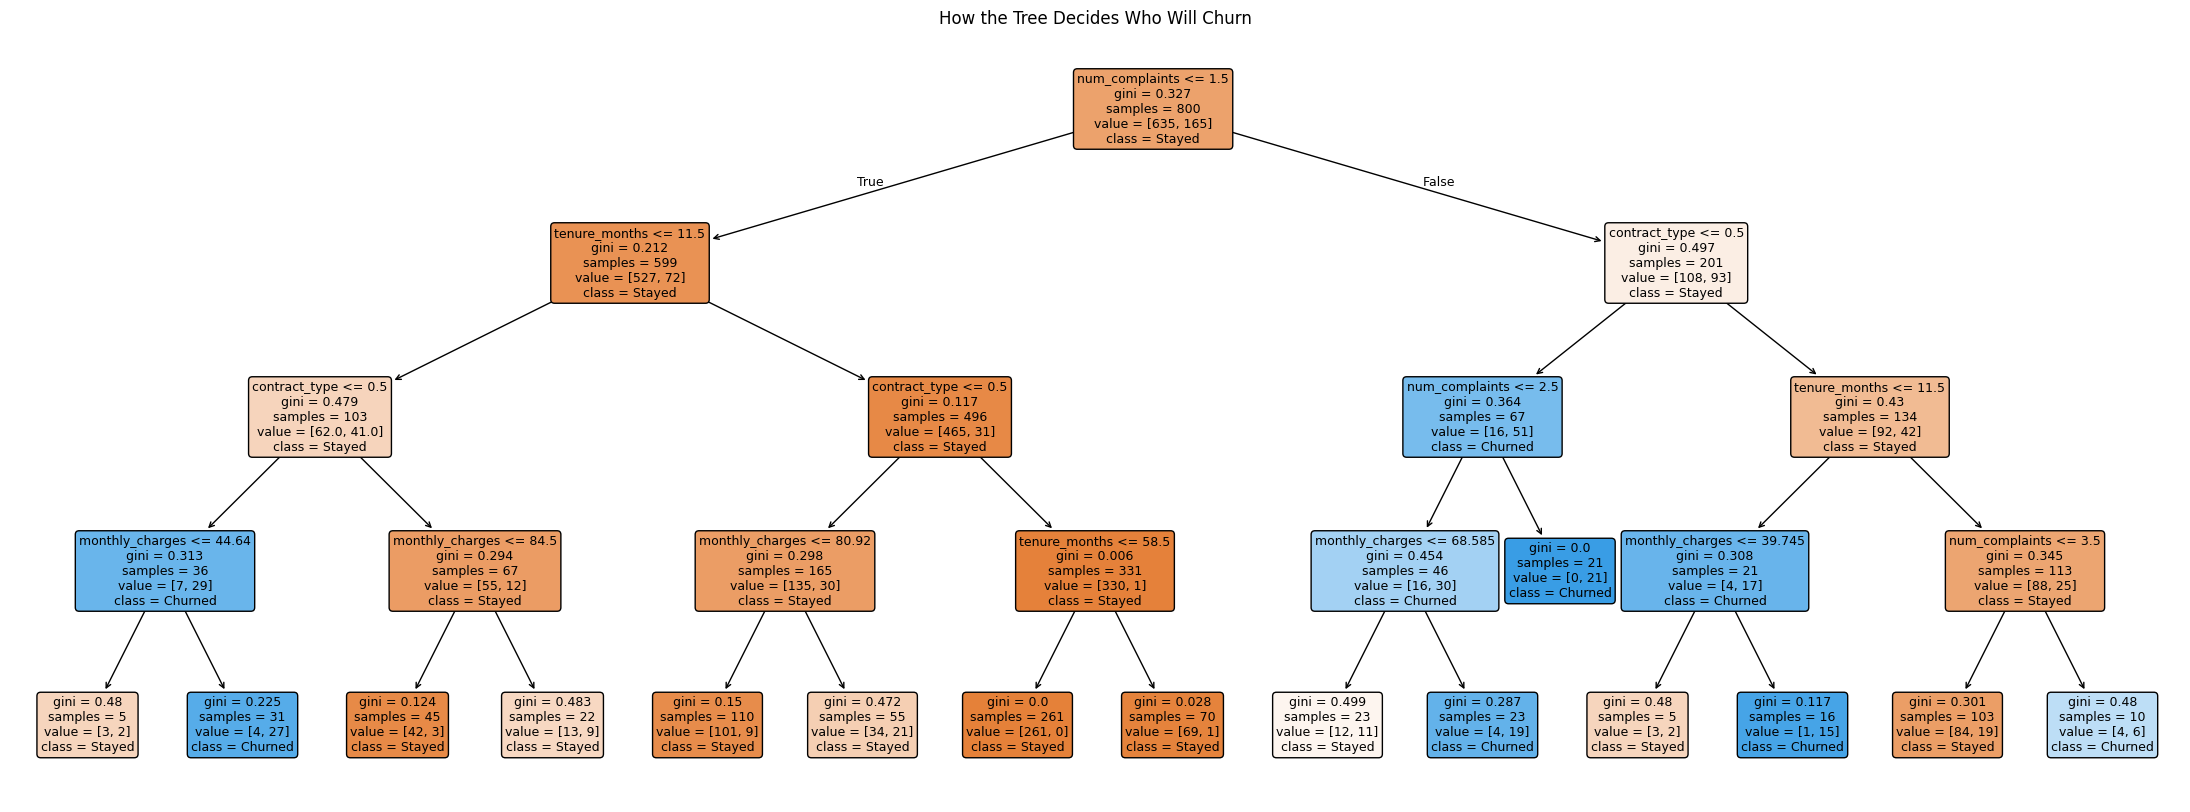

In [21]:
plt.figure(figsize=(28, 10))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=['Stayed', 'Churned'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("How the Tree Decides Who Will Churn")
plt.show()

#Which factor drive churn rate ?
(Businesses care MORE about this than the prediction)

In [22]:
importances = pd.Series(clf.feature_importances_,index = X.columns)
print("\nWhat drives churn (most → least important):")
print(importances.sort_values(ascending=False))


What drives churn (most → least important):
contract_type      0.324042
num_complaints     0.313662
tenure_months      0.235471
monthly_charges    0.126826
tech_support       0.000000
dtype: float64


## Predict Churn for a New Customer

In [23]:
# Define a new customer's data
new_customer_data = pd.DataFrame({
    'tenure_months': [10], # Example: short tenure
    'monthly_charges': [110.00], # Example: high monthly charges
    'contract_type': ['Month-to-month'], # Example: month-to-month contract
    'tech_support': ['No'], # Example: no tech support
    'num_complaints': [3] # Example: multiple complaints
})

# Apply the same LabelEncoder transformations
for column in ["contract_type", "tech_support"]:
    if column in new_customer_data.columns:
        le = label_encoders[column] # Use the previously fitted encoder
        new_customer_data[column] = le.transform(new_customer_data[column])

print("New customer data (encoded):")
display(new_customer_data)

# Make a prediction
new_customer_prediction = clf.predict(new_customer_data)

churn_status = 'Churned' if new_customer_prediction[0] == 1 else 'Stayed'
print(f"\nPrediction for new customer: {churn_status}")

New customer data (encoded):


,tenure_months,monthly_charges,contract_type,tech_support,num_complaints
0,10,110.0,0,0,3



Prediction for new customer: Churned
